In [64]:
from pathlib import Path
import pandas as pd

# ============================================================
# STREAMLIT EXPORT
# ============================================================

OUTPUT_DIR = Path.cwd().resolve().parent / "outputs"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. MODEL EVALUATION
# ============================================================

model_evaluation = pd.DataFrame({
    "Model": [
        "XGBoost (raw OOF)",
        "Calibrated XGBoost (OOF)"
    ],

    "ROC_AUC": [
        0.8404,
        0.8378
    ],

    "PR_AUC": [
        0.6499,
        0.6506
    ],

    "Brier_Score": [
        0.1378,
        0.1392
    ],

    "Log_Loss": [
        0.4238,
        0.4331
    ]
})

model_evaluation.to_csv(
    OUTPUT_DIR / "model_evaluation.csv",
    index=False
)

print("Created:")
print(OUTPUT_DIR / "model_evaluation.csv")


# ============================================================
# 2. CUSTOMER RISK SCORES
# ============================================================

# Notebook 7 already created customer_risk_scored.csv
old_risk_file = OUTPUT_DIR / "customer_risk_scored.csv"
new_risk_file = OUTPUT_DIR / "customer_risk_scores.csv"

if old_risk_file.exists():

    risk_data = pd.read_csv(old_risk_file)

    risk_data.to_csv(
        new_risk_file,
        index=False
    )

    print("Created:")
    print(new_risk_file)

else:

    print(
        "WARNING: customer_risk_scored.csv was not found."
    )


# ============================================================
# 3. FINAL CHECK
# ============================================================

print("\n========================================")
print("STREAMLIT FILES READY")
print("========================================")

print("\nOutputs folder:")
print(OUTPUT_DIR)

print("\nFiles:")

for file in OUTPUT_DIR.iterdir():

    if file.suffix.lower() in [
        ".csv",
        ".png",
        ".pkl",
        ".json"
    ]:
        print("-", file.name)

Created:
C:\Lang\Clg\TeleMetric\outputs\model_evaluation.csv

STREAMLIT FILES READY

Outputs folder:
C:\Lang\Clg\TeleMetric\outputs

Files:
- best_model_params.json
- best_xgboost_model.pkl
- calibrated_xgboost_model.pkl
- customer_risk_scores.csv
- model_comparison.csv
- model_evaluation.csv
- model_features.json
- retention_segment_summary.csv
- retention_strategy_comparison.csv
- shap_feature_importance.png
- top_100_retention_targets.csv
- xgboost_calibration_comparison.csv
- xgboost_probability_calibrator.pkl


In [57]:
# ============================================================
# SAVE MODEL EVALUATION RESULTS FOR STREAMLIT
# ============================================================

evaluation_results = pd.DataFrame([
    {
        "Model": "XGBoost",
        "ROC_AUC": raw_oof_roc_auc,
        "PR_AUC": raw_oof_pr_auc,
        "Brier_Score": raw_oof_brier,
        "Log_Loss": raw_oof_logloss
    },
    {
        "Model": "Calibrated XGBoost",
        "ROC_AUC": calibrated_oof_roc_auc,
        "PR_AUC": calibrated_oof_pr_auc,
        "Brier_Score": calibrated_oof_brier,
        "Log_Loss": calibrated_oof_logloss
    }
])

evaluation_results.to_csv(
    OUTPUT_DIR / "model_evaluation.csv",
    index=False
)

print("\nSaved model evaluation:")
print(evaluation_results)


Saved model evaluation:
                Model   ROC_AUC    PR_AUC  Brier_Score  Log_Loss
0             XGBoost  0.840419  0.649880     0.137798  0.423821
1  Calibrated XGBoost  0.837761  0.650605     0.139153  0.433072


In [56]:
# ============================================================
# CELL 6: FINAL MODEL + SAVE ARTIFACTS
# ============================================================

# ------------------------------------------------------------
# Train final XGBoost on ALL available data
# ------------------------------------------------------------

final_model = XGBClassifier(
    **XGB_PARAMS
)

final_model.fit(
    X,
    y
)


print(
    "\nFinal XGBoost model trained successfully."
)


# ------------------------------------------------------------
# Save final XGBoost model
# ------------------------------------------------------------

model_path = (
    OUTPUT_DIR
    / "best_xgboost_model.pkl"
)

joblib.dump(
    final_model,
    model_path
)


# ------------------------------------------------------------
# Save calibrator
# ------------------------------------------------------------

calibrator_path = (
    OUTPUT_DIR
    / "xgboost_probability_calibrator.pkl"
)

joblib.dump(
    calibrator,
    calibrator_path
)


# ------------------------------------------------------------
# Save feature list
# ------------------------------------------------------------

features_path = (
    OUTPUT_DIR
    / "model_features.json"
)

with open(
    features_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        model_features,
        f,
        indent=2
    )



# ============================================================
# CUSTOMER RISK OUTPUT COLUMNS
# ============================================================
# ============================================================
# SAVE CUSTOMER RISK SCORES
# ============================================================

risk_columns = [
    "customerID",
    "Churn_Target",
    "Churn_Probability",
    "Raw_Churn_Probability",
    "Risk_Band",
    "Contract",
    "InternetService",
    "tenure",
    "MonthlyCharges",
    "Estimated_Billed_Value",
    "Expected_Revenue_at_Risk",
    "Retention_Priority_Score",
    "Retention_Segment"
]


risk_output_path = (
    OUTPUT_DIR
    / "customer_risk_scores.csv"
)


data[risk_columns].to_csv(
    risk_output_path,
    index=False
)


print(
    "\nCustomer risk scores saved:"
)

print(
    risk_output_path
)

print(
    "\nExported columns:"
)

print(
    data[risk_columns].columns.tolist()
)


# ------------------------------------------------------------
# Save model evaluation
# ------------------------------------------------------------

evaluation_output = pd.DataFrame({
    "Model": [
        "XGBoost OOF",
        "Calibrated XGBoost OOF"
    ],
    "ROC_AUC": [
        oof_roc_auc,
        calibrated_roc_auc
    ],
    "PR_AUC": [
        oof_pr_auc,
        calibrated_pr_auc
    ],
    "Brier_Score": [
        oof_brier,
        calibrated_brier
    ],
    "Log_Loss": [
        oof_logloss,
        calibrated_logloss
    ]
})


evaluation_path = (
    OUTPUT_DIR
    / "xgboost_calibration_comparison.csv"
)

evaluation_output.to_csv(
    evaluation_path,
    index=False
)


# ============================================================
# VERIFY OUTPUTS
# ============================================================

print("\n==============================")
print("FILES SAVED")
print("==============================")

for path in [
    model_path,
    calibrator_path,
    features_path,
    risk_output_path,
    evaluation_path
]:

    print(
        f"{path.name}: "
        f"{'OK' if path.exists() else 'MISSING'}"
    )


# ------------------------------------------------------------
# Final sanity checks
# ------------------------------------------------------------

print("\n==============================")
print("FINAL SANITY CHECKS")
print("==============================")

print(
    "Customer rows:",
    len(data)
)

print(
    "Risk probabilities:",
    len(data["Churn_Probability"])
)

print(
    "Probability minimum:",
    data["Churn_Probability"].min()
)

print(
    "Probability maximum:",
    data["Churn_Probability"].max()
)

print(
    "Missing probabilities:",
    data["Churn_Probability"].isna().sum()
)

print(
    "Revenue at risk:",
    f"${total_revenue_risk:,.2f}"
)

print("\nPipeline completed successfully.")


Final XGBoost model trained successfully.

Customer risk scores saved:
c:\Lang\Clg\TeleMetric\outputs\customer_risk_scores.csv

Exported columns:
['customerID', 'Churn_Target', 'Churn_Probability', 'Raw_Churn_Probability', 'Risk_Band', 'Contract', 'InternetService', 'tenure', 'MonthlyCharges', 'Estimated_Billed_Value', 'Expected_Revenue_at_Risk', 'Retention_Priority_Score', 'Retention_Segment']

FILES SAVED
best_xgboost_model.pkl: OK
xgboost_probability_calibrator.pkl: OK
model_features.json: OK
customer_risk_scores.csv: OK
xgboost_calibration_comparison.csv: OK

FINAL SANITY CHECKS
Customer rows: 7032
Risk probabilities: 7032
Probability minimum: 0.0010884222574532032
Probability maximum: 0.9722011089324951
Missing probabilities: 0
Revenue at risk: $139,059.58

Pipeline completed successfully.


In [55]:
# ============================================================
# CELL 5: FINAL CUSTOMER RISK SCORES
# ============================================================

# ------------------------------------------------------------
# Attach raw and calibrated probabilities
# ------------------------------------------------------------

# ============================================================
# FINAL CUSTOMER RISK PROBABILITY
# ============================================================

data["Raw_Churn_Probability"] = (
    raw_oof_probabilities
)

# Raw XGBoost probabilities performed better on
# Brier Score and Log Loss than the calibrated version.
# Therefore these are used as the final risk probabilities.

data["Churn_Probability"] = (
    raw_oof_probabilities
)

# ------------------------------------------------------------
# Risk bands
# ------------------------------------------------------------

def risk_band(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.60:
        return "Medium"

    elif probability < 0.80:
        return "High"

    else:
        return "Critical"


data["Risk_Band"] = (
    data["Churn_Probability"]
    .apply(risk_band)
)


# ------------------------------------------------------------
# Estimated customer value
# ------------------------------------------------------------

data["Estimated_Billed_Value"] = (
    data["MonthlyCharges"]
    *
    data["tenure"]
)


# ------------------------------------------------------------
# Expected monthly revenue at risk
# ------------------------------------------------------------

data["Expected_Revenue_at_Risk"] = (
    data["Churn_Probability"]
    *
    data["MonthlyCharges"]
)


# ------------------------------------------------------------
# Total revenue at risk
# ------------------------------------------------------------

total_revenue_risk = (
    data["Expected_Revenue_at_Risk"]
    .sum()
)


# ------------------------------------------------------------
# Normalized customer value
# ------------------------------------------------------------

value_min = (
    data["Estimated_Billed_Value"]
    .min()
)

value_max = (
    data["Estimated_Billed_Value"]
    .max()
)

if value_max > value_min:

    data["Normalized_Value"] = (
        (
            data["Estimated_Billed_Value"]
            - value_min
        )
        /
        (
            value_max
            - value_min
        )
    )

else:

    data["Normalized_Value"] = 0


# ------------------------------------------------------------
# Retention priority score
# ------------------------------------------------------------

data["Retention_Priority_Score"] = (
    data["Churn_Probability"]
    *
    data["Normalized_Value"]
)


# ------------------------------------------------------------
# Retention segment
# ------------------------------------------------------------

value_median = (
    data["Estimated_Billed_Value"]
    .median()
)


def retention_segment(row):

    high_risk = (
        row["Churn_Probability"] >= 0.60
    )

    high_value = (
        row["Estimated_Billed_Value"]
        >= value_median
    )

    if high_risk and high_value:
        return "Priority Retention"

    elif high_risk and not high_value:
        return "Automated Retention"

    elif not high_risk and high_value:
        return "Loyal / High Value"

    else:
        return "Low Priority"


data["Retention_Segment"] = (
    data.apply(
        retention_segment,
        axis=1
    )
)


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("\n==============================")
print("RISK BAND DISTRIBUTION")
print("==============================")

print(
    data["Risk_Band"]
    .value_counts()
    .sort_index()
)


print("\n==============================")
print("TOTAL MONTHLY REVENUE AT RISK")
print("==============================")

print(
    f"${total_revenue_risk:,.2f}"
)


print("\n==============================")
print("TOP 10 HIGH-RISK CUSTOMERS")
print("==============================")

print(
    data[
        [
            "customerID",
            "Churn_Probability",
            "Risk_Band",
            "MonthlyCharges",
            "Expected_Revenue_at_Risk",
            "Retention_Priority_Score"
        ]
    ]
    .sort_values(
        "Churn_Probability",
        ascending=False
    )
    .head(10)
)


RISK BAND DISTRIBUTION
Risk_Band
Critical     344
High         743
Low         4443
Medium      1502
Name: count, dtype: int64

TOTAL MONTHLY REVENUE AT RISK
$139,059.58

TOP 10 HIGH-RISK CUSTOMERS
      customerID  Churn_Probability Risk_Band  MonthlyCharges  \
6473  5419-JPRRN           0.972201  Critical          101.45   
3530  2254-DLXRI           0.957623  Critical           79.15   
3374  5178-LMXOP           0.948234  Critical           95.10   
1595  3068-OMWZA           0.947498  Critical           88.80   
584   5192-EBGOV           0.945422  Critical           85.70   
4792  9300-AGZNL           0.943299  Critical           94.00   
3204  8149-RSOUN           0.942132  Critical           93.85   
2275  2754-SDJRD           0.941475  Critical          100.15   
6855  0295-PPHDO           0.938013  Critical           95.45   
1699  0107-YHINA           0.935570  Critical           99.75   

      Expected_Revenue_at_Risk  Retention_Priority_Score  
6473                 98.62

In [54]:
# ============================================================
# CELL 4: FINAL CALIBRATOR FOR DEPLOYMENT
# ============================================================

# ------------------------------------------------------------
# Fit one final calibration model using ALL
# out-of-fold XGBoost predictions.
#
# Important:
# The performance evaluation above was already performed
# using cross-fitted validation predictions.
#
# This calibrator is now being fitted for deployment so that
# the final XGBoost probabilities can be transformed into
# calibrated probabilities later.
# ------------------------------------------------------------

final_calibrator = LogisticRegression(
    solver="lbfgs",
    random_state=42
)


final_calibrator.fit(
    raw_oof_probabilities.reshape(-1, 1),
    y
)


print(
    "Final probability calibrator trained successfully."
)


# ------------------------------------------------------------
# Save final calibrator in memory for Cell 6
# ------------------------------------------------------------

calibrator = final_calibrator


# ------------------------------------------------------------
# Display probability ranges
# ------------------------------------------------------------

print(
    "\nRaw OOF probability range:"
)

print(
    f"Min: {raw_oof_probabilities.min():.4f}"
)

print(
    f"Max: {raw_oof_probabilities.max():.4f}"
)


print(
    "\nCross-fitted calibrated probability range:"
)

print(
    f"Min: {calibrated_oof_probabilities.min():.4f}"
)

print(
    f"Max: {calibrated_oof_probabilities.max():.4f}"
)

Final probability calibrator trained successfully.

Raw OOF probability range:
Min: 0.0011
Max: 0.9722

Cross-fitted calibrated probability range:
Min: 0.0649
Max: 0.8784


In [61]:
# ============================================================
# CELL 3: CROSS-FITTED OOF + CALIBRATED PREDICTIONS
# ============================================================

from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split
)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss
)

from sklearn.linear_model import LogisticRegression

import numpy as np
import pandas as pd


# ============================================================
# XGBOOST PARAMETERS
# ============================================================

XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 4,
    "learning_rate": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "eval_metric": "logloss",
    "random_state": 42
}


# ============================================================
# OUTER 5-FOLD CROSS-VALIDATION
# ============================================================

outer_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================================
# STORAGE
# ============================================================

raw_oof_probabilities = np.zeros(
    len(X),
    dtype=float
)

calibrated_oof_probabilities = np.zeros(
    len(X),
    dtype=float
)


# ============================================================
# FOLD LOOP
# ============================================================

for fold, (outer_train_idx, outer_valid_idx) in enumerate(
    outer_cv.split(X, y),
    start=1
):

    print(
        f"\n========================================"
        f"\nOUTER FOLD {fold}"
        f"\n========================================"
    )


    # --------------------------------------------------------
    # Outer training and validation data
    # --------------------------------------------------------

    X_outer_train = X.iloc[outer_train_idx]
    y_outer_train = y.iloc[outer_train_idx]

    X_outer_valid = X.iloc[outer_valid_idx]
    y_outer_valid = y.iloc[outer_valid_idx]


    # --------------------------------------------------------
    # Split outer training data into:
    #
    # 1. Model training portion
    # 2. Calibration portion
    # --------------------------------------------------------

    (
        X_model_train,
        X_calibration,
        y_model_train,
        y_calibration
    ) = train_test_split(
        X_outer_train,
        y_outer_train,
        test_size=0.20,
        random_state=42,
        stratify=y_outer_train
    )


    # ========================================================
    # TRAIN XGBOOST
    # ========================================================

    fold_model = XGBClassifier(
        **XGB_PARAMS
    )

    fold_model.fit(
        X_model_train,
        y_model_train
    )


    # ========================================================
    # RAW PROBABILITIES
    # ========================================================

    calibration_probabilities = (
        fold_model
        .predict_proba(X_calibration)[:, 1]
    )

    outer_valid_raw_probabilities = (
        fold_model
        .predict_proba(X_outer_valid)[:, 1]
    )


    # ========================================================
    # FIT CALIBRATOR
    # ========================================================

    fold_calibrator = LogisticRegression(
        solver="lbfgs",
        random_state=42
    )

    fold_calibrator.fit(
        calibration_probabilities.reshape(-1, 1),
        y_calibration
    )


    # ========================================================
    # RAW OUTER VALIDATION PROBABILITIES
    # ========================================================

    raw_oof_probabilities[outer_valid_idx] = (
        outer_valid_raw_probabilities
    )


    # ========================================================
    # CALIBRATED OUTER VALIDATION PROBABILITIES
    # ========================================================

    outer_valid_calibrated_probabilities = (
        fold_calibrator
        .predict_proba(
            outer_valid_raw_probabilities.reshape(-1, 1)
        )[:, 1]
    )


    calibrated_oof_probabilities[
        outer_valid_idx
    ] = outer_valid_calibrated_probabilities


    # ========================================================
    # FOLD METRICS
    # ========================================================

    raw_fold_auc = roc_auc_score(
        y_outer_valid,
        outer_valid_raw_probabilities
    )

    calibrated_fold_auc = roc_auc_score(
        y_outer_valid,
        outer_valid_calibrated_probabilities
    )


    raw_fold_brier = brier_score_loss(
        y_outer_valid,
        outer_valid_raw_probabilities
    )

    calibrated_fold_brier = brier_score_loss(
        y_outer_valid,
        outer_valid_calibrated_probabilities
    )


    raw_fold_logloss = log_loss(
        y_outer_valid,
        outer_valid_raw_probabilities
    )

    calibrated_fold_logloss = log_loss(
        y_outer_valid,
        outer_valid_calibrated_probabilities
    )


    print(
        f"Raw ROC-AUC        : {raw_fold_auc:.4f}"
    )

    print(
        f"Calibrated ROC-AUC : {calibrated_fold_auc:.4f}"
    )

    print(
        f"Raw Brier          : {raw_fold_brier:.4f}"
    )

    print(
        f"Calibrated Brier   : {calibrated_fold_brier:.4f}"
    )

    print(
        f"Raw Log Loss       : {raw_fold_logloss:.4f}"
    )

    print(
        f"Calibrated Log Loss: {calibrated_fold_logloss:.4f}"
    )


# ============================================================
# VERIFY OOF COMPLETENESS
# ============================================================

print(
    "\nMissing raw OOF predictions:",
    np.isnan(raw_oof_probabilities).sum()
)

print(
    "Missing calibrated OOF predictions:",
    np.isnan(calibrated_oof_probabilities).sum()
)


# ============================================================
# OVERALL RAW METRICS
# ============================================================

raw_oof_roc_auc = roc_auc_score(
    y,
    raw_oof_probabilities
)

raw_oof_pr_auc = average_precision_score(
    y,
    raw_oof_probabilities
)

raw_oof_brier = brier_score_loss(
    y,
    raw_oof_probabilities
)

raw_oof_logloss = log_loss(
    y,
    raw_oof_probabilities
)


# ============================================================
# OVERALL CALIBRATED METRICS
# ============================================================

calibrated_oof_roc_auc = roc_auc_score(
    y,
    calibrated_oof_probabilities
)

calibrated_oof_pr_auc = average_precision_score(
    y,
    calibrated_oof_probabilities
)

calibrated_oof_brier = brier_score_loss(
    y,
    calibrated_oof_probabilities
)

calibrated_oof_logloss = log_loss(
    y,
    calibrated_oof_probabilities
)


# ============================================================
# FINAL COMPARISON
# ============================================================

cross_fitted_calibration_comparison = pd.DataFrame({

    "Metric": [
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "Log Loss"
    ],

    "Raw XGBoost": [
        raw_oof_roc_auc,
        raw_oof_pr_auc,
        raw_oof_brier,
        raw_oof_logloss
    ],

    "Cross-Fitted Calibrated XGBoost": [
        calibrated_oof_roc_auc,
        calibrated_oof_pr_auc,
        calibrated_oof_brier,
        calibrated_oof_logloss
    ]
})


print(
    "\n========================================"
    "\nCROSS-FITTED CALIBRATION RESULTS"
    "\n========================================"
)

print(
    cross_fitted_calibration_comparison.round(4)
)


OUTER FOLD 1
Raw ROC-AUC        : 0.8373
Calibrated ROC-AUC : 0.8373
Raw Brier          : 0.1398
Calibrated Brier   : 0.1404
Raw Log Loss       : 0.4296
Calibrated Log Loss: 0.4372

OUTER FOLD 2
Raw ROC-AUC        : 0.8511
Calibrated ROC-AUC : 0.8511
Raw Brier          : 0.1339
Calibrated Brier   : 0.1362
Raw Log Loss       : 0.4109
Calibrated Log Loss: 0.4266

OUTER FOLD 3
Raw ROC-AUC        : 0.8365
Calibrated ROC-AUC : 0.8365
Raw Brier          : 0.1416
Calibrated Brier   : 0.1431
Raw Log Loss       : 0.4284
Calibrated Log Loss: 0.4405

OUTER FOLD 4
Raw ROC-AUC        : 0.8417
Calibrated ROC-AUC : 0.8417
Raw Brier          : 0.1363
Calibrated Brier   : 0.1378
Raw Log Loss       : 0.4227
Calibrated Log Loss: 0.4288

OUTER FOLD 5
Raw ROC-AUC        : 0.8355
Calibrated ROC-AUC : 0.8355
Raw Brier          : 0.1375
Calibrated Brier   : 0.1383
Raw Log Loss       : 0.4275
Calibrated Log Loss: 0.4323

Missing raw OOF predictions: 0
Missing calibrated OOF predictions: 0

CROSS-FITTED CALIBR

In [52]:
# ============================================================
# CELL 2: PREPARE FEATURES
# ============================================================

# ------------------------------------------------------------
# Separate features and target
# ------------------------------------------------------------

X_raw = data.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Target"
    ],
    errors="ignore"
)

y = data["Churn_Target"].astype(int)


# ------------------------------------------------------------
# Convert categorical variables to numeric
# ------------------------------------------------------------

X = pd.get_dummies(
    X_raw,
    drop_first=True
)


# ------------------------------------------------------------
# Handle missing values
# ------------------------------------------------------------

X = X.fillna(
    X.median(numeric_only=True)
)

X = X.fillna(0)


# ------------------------------------------------------------
# Ensure every feature is numeric
# ------------------------------------------------------------

X = X.astype(float)


# ------------------------------------------------------------
# Store feature names
# ------------------------------------------------------------

model_features = X.columns.tolist()


# ------------------------------------------------------------
# Display information
# ------------------------------------------------------------

print("Feature matrix shape:")
print(X.shape)

print("\nNumber of model features:")
print(len(model_features))

print("\nFirst 20 features:")
print(model_features[:20])

print("\nTarget shape:")
print(y.shape)

print("\nTarget counts:")
print(y.value_counts())

Feature matrix shape:
(7032, 38)

Number of model features:
38

First 20 features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Service_Count', 'Estimated_Billed_Value', 'Charge_per_Tenure_Month', 'Streaming_Adoption', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes']

Target shape:
(7032,)

Target counts:
Churn_Target
0    5163
1    1869
Name: count, dtype: int64


In [51]:
# ============================================================
# TELEMETRIC - RISK SCORING PIPELINE
# CELL 1: IMPORTS, PATHS AND DATA
# ============================================================

from pathlib import Path
import json
import joblib

import numpy as np
import pandas as pd

from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression


# ============================================================
# FIND PROJECT ROOT
# ============================================================

def find_project_root():
    """
    Find the TeleMetric project root regardless of
    whether the notebook is launched from the root
    folder or the notebooks folder.
    """

    current = Path.cwd()

    candidates = [
        current,
        current.parent,
        current.parent.parent
    ]

    for candidate in candidates:

        data_path = (
            candidate
            / "data"
            / "processed"
            / "customer_master.csv"
        )

        if data_path.exists():
            return candidate

    raise FileNotFoundError(
        "Could not find TeleMetric project root. "
        "Make sure customer_master.csv exists at "
        "data/processed/customer_master.csv."
    )


BASE_DIR = find_project_root()

DATA_PATH = (
    BASE_DIR
    / "data"
    / "processed"
    / "customer_master.csv"
)

OUTPUT_DIR = (
    BASE_DIR
    / "outputs"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# LOAD DATA
# ============================================================

data = pd.read_csv(DATA_PATH)

print("Project root:")
print(BASE_DIR)

print("\nDataset shape:")
print(data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nTarget distribution:")
print(
    data["Churn_Target"]
    .value_counts()
)

Project root:
c:\Lang\Clg\TeleMetric

Dataset shape:
(7032, 27)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Target', 'Tenure_Group', 'Service_Count', 'Estimated_Billed_Value', 'Charge_per_Tenure_Month', 'Streaming_Adoption']

Target distribution:
Churn_Target
0    5163
1    1869
Name: count, dtype: int64


In [50]:
model_results = pd.read_csv("../outputs/model_comparison.csv")

model_results

,Model,ROC_AUC,ROC_AUC_STD
0,Logistic Regression,0.847274,0.004161
1,Random Forest,0.829359,0.004643
2,XGBoost,0.843605,0.003615


In [49]:
from sklearn.model_selection import train_test_split

X = data.drop(
    columns=["customerID", "Churn", "Churn_Target"],
    errors="ignore"
)

y = data["Churn_Target"]

X = pd.get_dummies(
    X,
    drop_first=True
)

X = X.reindex(
    columns=model_features,
    fill_value=0
)

X = X.fillna(0)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (5625, 38)
X_test: (1407, 38)


In [48]:
import pandas as pd
import json

data = pd.read_csv("../data/processed/customer_master.csv")

with open("../outputs/model_features.json", "r") as f:
    model_features = json.load(f)

print("Dataset shape:", data.shape)
print("Number of model features:", len(model_features))



Dataset shape: (7032, 27)
Number of model features: 38


In [47]:
import joblib

joblib.dump(
    calibrated_model,
    "../outputs/calibrated_xgboost_model.pkl"
)

print("Calibrated XGBoost model saved.")

Calibrated XGBoost model saved.


In [46]:
# Generate calibrated churn probabilities
data["Churn_Probability"] = calibrated_model.predict_proba(
    X_calibration
)[:, 1]

print(data["Churn_Probability"].describe())

data["Risk_Band"] = pd.cut(
    data["Churn_Probability"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=["Low", "Medium", "High", "Critical"],
    include_lowest=True
)

data["Risk_Band"] = pd.cut(
    data["Churn_Probability"],
    bins=[0, 0.30, 0.60, 0.80, 1.00],
    labels=["Low", "Medium", "High", "Critical"],
    include_lowest=True
)

data["Retention_Priority_Score"] = (
    data["Churn_Probability"] *
    data["Normalized_Value"]
)

priority_customers = (
    data
    .sort_values(
        "Retention_Priority_Score",
        ascending=False
    )
)

priority_customers.to_csv(
    "../outputs/customer_risk_scores.csv",
    index=False
)

print("Updated calibrated customer risk scores saved.")

count    7032.000000
mean        0.268051
std         0.241780
min         0.066780
25%         0.077358
50%         0.143053
75%         0.406203
max         0.891925
Name: Churn_Probability, dtype: float64
Updated calibrated customer risk scores saved.


Calibration curve saved to:
C:\Lang\Clg\TeleMetric\outputs\xgboost_calibration_curve.png


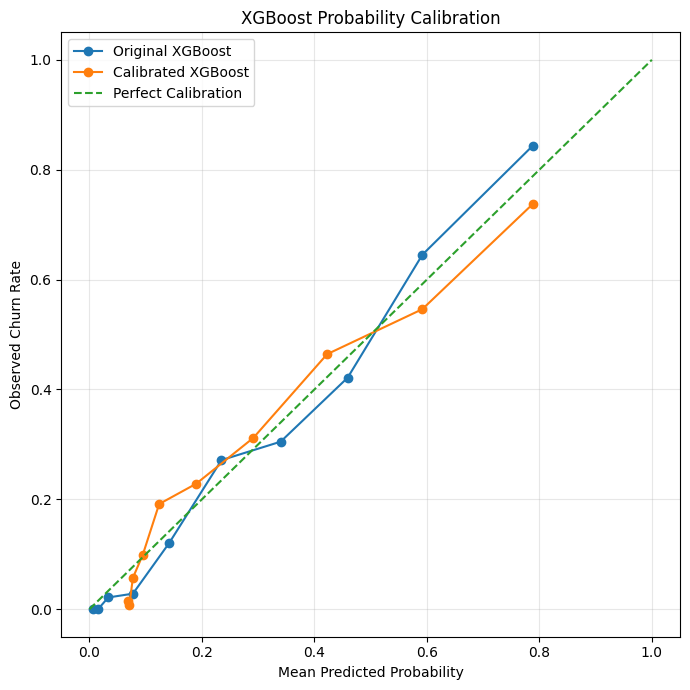

In [77]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# XGBOOST PROBABILITY CALIBRATION
# ============================================================

# Original / Raw XGBoost
prob_true_original, prob_pred_original = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=10,
    strategy="quantile"
)


# Calibrated XGBoost
prob_true_calibrated, prob_pred_calibrated = calibration_curve(
    y_test,
    calibrated_probabilities,
    n_bins=10,
    strategy="quantile"
)


# ============================================================
# CREATE CALIBRATION CURVE
# ============================================================

plt.figure(figsize=(7, 7))

# Raw XGBoost
plt.plot(
    prob_pred_original,
    prob_true_original,
    marker="o",
    label="Original XGBoost"
)

# Calibrated XGBoost
plt.plot(
    prob_pred_calibrated,
    prob_true_calibrated,
    marker="o",
    label="Calibrated XGBoost"
)

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("XGBoost Probability Calibration")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()


# ============================================================
# SAVE PNG FOR STREAMLIT
# ============================================================

OUTPUT_DIR = Path(OUTPUT_DIR)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CALIBRATION_PATH = (
    OUTPUT_DIR
    / "xgboost_calibration_curve.png"
)

plt.savefig(
    CALIBRATION_PATH,
    dpi=160,
    bbox_inches="tight"
)

print(
    "Calibration curve saved to:"
)

print(CALIBRATION_PATH)

plt.show()

In [44]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(
    X_train,
    y_train
)

calibrated_probabilities = calibrated_model.predict_proba(
    X_test
)[:, 1]
original_brier = brier_score_loss(
    y_test,
    test_probabilities
)

calibrated_brier = brier_score_loss(
    y_test,
    calibrated_probabilities
)

print("Original XGBoost Brier Score:", original_brier)
print("Calibrated XGBoost Brier Score:", calibrated_brier)

Original XGBoost Brier Score: 0.11617641333560362
Calibrated XGBoost Brier Score: 0.1429277250148942


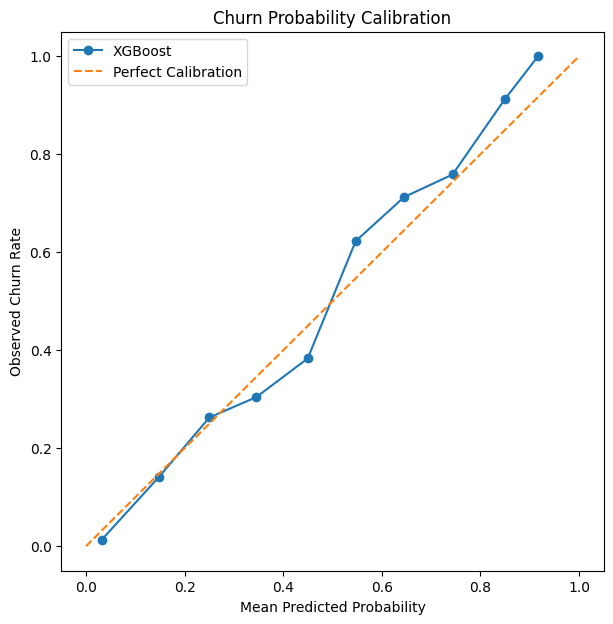

In [75]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

test_probabilities = best_model.predict_proba(
    X_test
)[:, 1]

prob_true, prob_pred = calibration_curve(
    y_test,
    test_probabilities,
    n_bins=10
)

plt.figure(figsize=(7, 7))

plt.plot(
    prob_pred,
    prob_true,
    marker="o",
    label="XGBoost"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Churn Rate")
plt.title("Churn Probability Calibration")
plt.legend()
plt.show()

In [42]:
from sklearn.model_selection import train_test_split

# Target
y = data["Churn_Target"]

# Features
X_calibration = data.drop(
    columns=["customerID", "Churn", "Churn_Target"],
    errors="ignore"
)

# Convert categorical variables
X_calibration = pd.get_dummies(
    X_calibration,
    drop_first=True
)

# Match the exact features used by the trained model
X_calibration = X_calibration.reindex(
    columns=model_features,
    fill_value=0
)

# Fill missing values
X_calibration = X_calibration.fillna(0)

# Create test set
X_train, X_test, y_train, y_test = train_test_split(
    X_calibration,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (1407, 38)
y_test shape: (1407,)


In [41]:
import json

with open("../outputs/model_features.json", "r") as f:
    model_features = json.load(f)

print("Number of model features:", len(model_features))
print("First 10 features:", model_features[:10])

Number of model features: 38
First 10 features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Service_Count', 'Estimated_Billed_Value', 'Charge_per_Tenure_Month', 'Streaming_Adoption', 'gender_Male', 'Partner_Yes']


In [40]:
priority_customers[
    [
        "customerID",
        "Contract",
        "tenure",
        "MonthlyCharges",
        "Churn_Probability",
        "Risk_Band",
        "Estimated_Billed_Value",
        "Expected_Revenue_at_Risk",
        "Retention_Segment"
    ]
].head(100).to_csv(
    "../outputs/top_100_retention_targets.csv",
    index=False
)

print("Top 100 retention targets saved.")

KeyError: "['Retention_Segment'] not in index"

In [39]:
data.to_csv(
    "../outputs/customer_risk_scores.csv",
    index=False
)

segment_summary.to_csv(
    "../outputs/retention_segment_summary.csv"
)

strategy_results.to_csv(
    "../outputs/retention_strategy_comparison.csv",
    index=False
)

print("All risk-scoring outputs saved successfully.")

All risk-scoring outputs saved successfully.


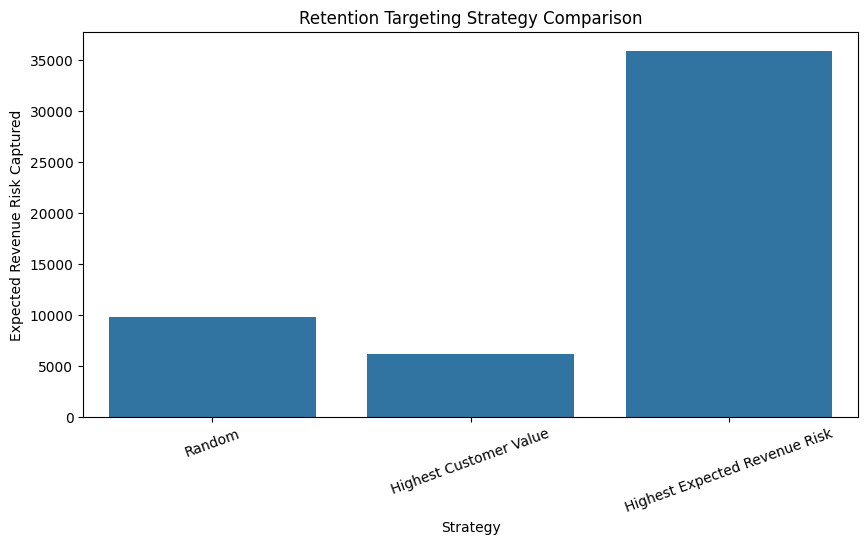

In [38]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=strategy_results,
    x="Strategy",
    y="Expected Revenue Risk Captured"
)

plt.title(
    "Retention Targeting Strategy Comparison"
)

plt.xlabel("Strategy")
plt.ylabel(
    "Expected Revenue Risk Captured"
)

plt.xticks(rotation=20)

plt.show()

In [37]:
random_sample = data.sample(
    RETENTION_CAPACITY,
    random_state=42
)

random_risk = (
    random_sample[
        "Expected_Revenue_at_Risk"
    ].sum()
)

value_sample = (
    data
    .sort_values(
        "Estimated_Billed_Value",
        ascending=False
    )
    .head(RETENTION_CAPACITY)
)

value_risk = (
    value_sample[
        "Expected_Revenue_at_Risk"
    ].sum()
)

risk_sample = (
    data
    .sort_values(
        "Expected_Revenue_at_Risk",
        ascending=False
    )
    .head(RETENTION_CAPACITY)
)

risk_based_risk = (
    risk_sample[
        "Expected_Revenue_at_Risk"
    ].sum()
)

strategy_results = pd.DataFrame({
    "Strategy": [
        "Random",
        "Highest Customer Value",
        "Highest Expected Revenue Risk"
    ],
    "Expected Revenue Risk Captured": [
        random_risk,
        value_risk,
        risk_based_risk
    ]
})

strategy_results

,Strategy,Expected Revenue Risk Captured
0,Random,9780.562655
1,Highest Customer Value,6206.057358
2,Highest Expected Revenue Risk,35917.961325


In [36]:
RETENTION_CAPACITY = 500
top_risk = (
    data
    .sort_values(
        "Expected_Revenue_at_Risk",
        ascending=False
    )
    .head(RETENTION_CAPACITY)
)

captured_revenue_risk = (
    top_risk["Expected_Revenue_at_Risk"]
    .sum()
)

coverage = (
    captured_revenue_risk
    /
    total_revenue_risk
)

print(
    f"Top {RETENTION_CAPACITY} customers capture "
    f"{coverage:.2%} of modeled revenue risk."
)

Top 500 customers capture 25.88% of modeled revenue risk.


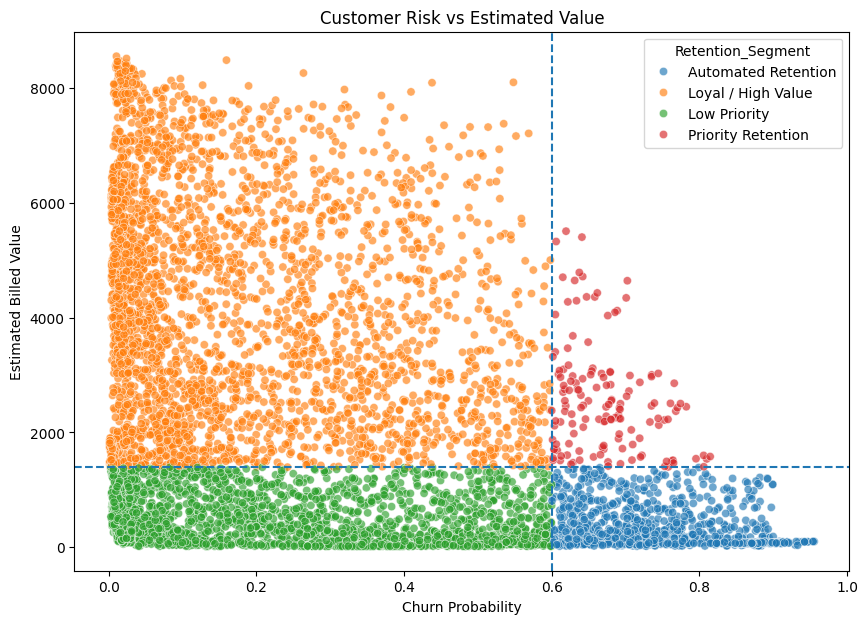

In [35]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=data,
    x="Churn_Probability",
    y="Estimated_Billed_Value",
    hue="Retention_Segment",
    alpha=0.65
)

plt.axvline(
    0.60,
    linestyle="--"
)

plt.axhline(
    value_median,
    linestyle="--"
)

plt.title(
    "Customer Risk vs Estimated Value"
)

plt.xlabel("Churn Probability")
plt.ylabel("Estimated Billed Value")

plt.show()

In [34]:
segment_summary = (
    data
    .groupby("Retention_Segment")
    .agg(
        Customers=("customerID", "count"),
        Avg_Churn_Risk=("Churn_Probability", "mean"),
        Total_Revenue_Risk=(
            "Expected_Revenue_at_Risk",
            "sum"
        ),
        Avg_Monthly_Charge=(
            "MonthlyCharges",
            "mean"
        )
    )
    .sort_values(
        "Total_Revenue_Risk",
        ascending=False
    )
)

segment_summary

,Customers,Avg_Churn_Risk,Total_Revenue_Risk,Avg_Monthly_Charge
Retention_Segment,,,,
Automated Retention,878,0.756915,51330.346176,76.747722
Loyal / High Value,3372,0.165442,49820.071993,80.542141
Low Priority,2638,0.207411,28303.729822,38.978336
Priority Retention,144,0.672592,9336.927862,96.274653


In [33]:
value_median = data[
    "Estimated_Billed_Value"
].median()

data["High_Value"] = (
    data["Estimated_Billed_Value"]
    >= value_median
)

data["High_Risk"] = (
    data["Churn_Probability"]
    >= 0.60
)

def retention_segment(row):

    if row["High_Value"] and row["High_Risk"]:
        return "Priority Retention"

    elif not row["High_Value"] and row["High_Risk"]:
        return "Automated Retention"

    elif row["High_Value"] and not row["High_Risk"]:
        return "Loyal / High Value"

    else:
        return "Low Priority"


data["Retention_Segment"] = (
    data.apply(
        retention_segment,
        axis=1
    )
)

In [32]:
data["Retention_Priority_Score"] = (
    data["Churn_Probability"]
    *
    data["Normalized_Value"]
)

priority_customers = (
    data
    .sort_values(
        "Retention_Priority_Score",
        ascending=False
    )
)

priority_customers[
    [
        "customerID",
        "Churn_Probability",
        "Risk_Band",
        "MonthlyCharges",
        "Estimated_Billed_Value",
        "Expected_Revenue_at_Risk",
        "Retention_Priority_Score"
    ]
].head(20)

,customerID,Churn_Probability,Risk_Band,MonthlyCharges,Estimated_Billed_Value,Expected_Revenue_at_Risk,Retention_Priority_Score
6528,1444-VVSGW,0.548244,Medium,115.65,8095.50,63.404391,0.519036
2874,4550-VBOFE,0.568906,Medium,102.95,7206.50,58.568892,0.479314
6023,9090-SGQXL,0.551688,Medium,105.30,7160.40,58.092792,0.461827
6007,4250-ZBWLV,0.535077,Medium,108.45,7374.60,58.029124,0.461356
6026,9835-ZIITK,0.513930,Medium,110.85,7316.10,56.969163,0.439599
1335,3838-OZURD,0.528964,Medium,105.00,6930.00,55.541268,0.428519
6596,7632-MNYOY,0.489465,Medium,110.90,7319.40,54.281675,0.418861
1302,0201-OAMXR,0.437988,Medium,115.55,8088.50,50.609477,0.414294
2277,1587-FKLZB,0.529586,Medium,99.50,6567.00,52.693791,0.406488
3405,7056-IMHCC,0.641015,High,101.90,5400.70,65.319397,0.404384


In [31]:
value_min = data[
    "Estimated_Billed_Value"
].min()

value_max = data[
    "Estimated_Billed_Value"
].max()

data["Normalized_Value"] = (
    (
        data["Estimated_Billed_Value"]
        - value_min
    )
    /
    (
        value_max
        - value_min
    )
)

In [30]:
data["Expected_Revenue_at_Risk"] = (
    data["Churn_Probability"]
    *
    data["MonthlyCharges"]
)

total_revenue_risk = (
    data["Expected_Revenue_at_Risk"]
    .sum()
)

print(
    f"Expected monthly revenue at risk: "
    f"${total_revenue_risk:,.2f}"
)

Expected monthly revenue at risk: $138,791.08


In [29]:
data["Estimated_Billed_Value"] = (
    data["MonthlyCharges"] *
    data["tenure"]
)

data[
    [
        "customerID",
        "tenure",
        "MonthlyCharges",
        "Estimated_Billed_Value"
    ]
].head(10)

,customerID,tenure,MonthlyCharges,Estimated_Billed_Value
0,7590-VHVEG,1,29.85,29.85
1,5575-GNVDE,34,56.95,1936.30
2,3668-QPYBK,2,53.85,107.70
3,7795-CFOCW,45,42.30,1903.50
4,9237-HQITU,2,70.70,141.40
5,9305-CDSKC,8,99.65,797.20
6,1452-KIOVK,22,89.10,1960.20
7,6713-OKOMC,10,29.75,297.50
8,7892-POOKP,28,104.80,2934.40
9,6388-TABGU,62,56.15,3481.30


In [28]:
risk_validation = (
    data
    .groupby("Risk_Band")
    .agg(
        Customers=("customerID", "count"),
        Average_Risk=("Churn_Probability", "mean"),
        Actual_Churn_Rate=("Churn_Target", "mean")
    )
)

risk_validation["Actual_Churn_Rate"] *= 100

risk_validation

,Customers,Average_Risk,Actual_Churn_Rate
Risk_Band,,,
Critical,321,0.864111,92.834891
High,701,0.690507,76.747504
Low,4391,0.089627,6.627192
Medium,1619,0.439449,45.830760


In [27]:
def risk_band(probability):

    if probability < 0.30:
        return "Low"

    elif probability < 0.60:
        return "Medium"

    elif probability < 0.80:
        return "High"

    else:
        return "Critical"


data["Risk_Band"] = (
    data["Churn_Probability"]
    .apply(risk_band)
)


print(
    data["Risk_Band"]
    .value_counts()
)

Risk_Band
Low         4391
Medium      1619
High         701
Critical     321
Name: count, dtype: int64


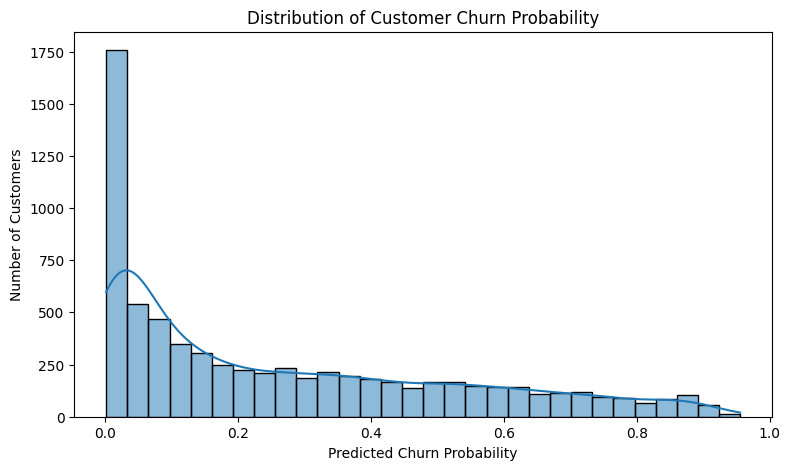

In [26]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data["Churn_Probability"],
    bins=30,
    kde=True
)

plt.title("Distribution of Customer Churn Probability")
plt.xlabel("Predicted Churn Probability")
plt.ylabel("Number of Customers")

plt.show()

In [16]:
print(
    data["Churn_Probability"].describe()
)

count    7032.000000
mean        0.417120
std         0.297191
min         0.023710
25%         0.119499
50%         0.392277
75%         0.690164
max         0.965432
Name: Churn_Probability, dtype: float64


In [25]:
data["Churn_Probability"] = (
    best_model.predict_proba(X)[:, 1]
)

print(
    data[
        [
            "customerID",
            "Churn_Probability"
        ]
    ].head(10)
)

   customerID  Churn_Probability
0  7590-VHVEG           0.695347
1  5575-GNVDE           0.025051
2  3668-QPYBK           0.369510
3  7795-CFOCW           0.028722
4  9237-HQITU           0.620317
5  9305-CDSKC           0.882245
6  1452-KIOVK           0.379707
7  6713-OKOMC           0.202511
8  7892-POOKP           0.641924
9  6388-TABGU           0.022622


In [24]:
X = X.reindex(
    columns=feature_columns,
    fill_value=0
)

print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (7032, 38)


In [23]:
import json

with open(
    "../outputs/model_features.json",
    "r"
) as f:
    feature_columns = json.load(f)

print("Number of model features:", len(feature_columns))

Number of model features: 38


In [22]:
X_raw = data.drop(
    columns=[
        "customerID",
        "Churn",
        "Churn_Target"
    ],
    errors="ignore"
)

X = pd.get_dummies(
    X_raw,
    drop_first=True
)

X = X.fillna(
    X.median(numeric_only=True)
)

X = X.fillna(0)

print("Feature matrix shape:", X.shape)

Feature matrix shape: (7032, 38)


In [21]:
model_path = "../outputs/best_xgboost_model.pkl"

best_model = joblib.load(model_path)

print("Best XGBoost model loaded successfully!")
print(best_model)

Best XGBoost model loaded successfully!
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)


In [20]:
data = pd.read_csv(
    "../data/processed/customer_master.csv"
)

print("Dataset shape:", data.shape)
print("\nColumns:")
print(data.columns.tolist())

Dataset shape: (7032, 27)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'Churn_Target', 'Tenure_Group', 'Service_Count', 'Estimated_Billed_Value', 'Charge_per_Tenure_Month', 'Streaming_Adoption']


In [19]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

print("Imports successful!")

Imports successful!
